# Анализ цен на недвижимость в Москве

В рамках группового проекта рассматривается задача анализа рынка жилой недвижимости Москвы и создания модели, позволяющей оценивать стоимость квартиры по ее характеристикам.

Ранее для задачи анализа данных и построения модели был собран датасет через парсингом объявлений с сайта Домклик. Дополнительно данные были расширены с помощью запроса данных от внешних API: геокодинга, поиска инфраструктуры рядом с объектом недвижимости, определения района, оценки качества воздуха и расстоянием до центра города.

Цель данного этапа работы - очистить данные, определить наиболее значимые факторы, влияющие на цену квартиры, проверить несколько исследовательских гипотез и подготовить признаки для последующего построения модели прогнозирования.

#1. Загрузка и первичный обзор данных

In [ ]:
import pandas as pd
import numpy as np
import requests

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


Разместим наш dataframe на гугл диске, для простоты открытия, и посмотрим на него

In [ ]:
url = ('https://drive.google.com/file/d/1jPoyNu4NpFxyJoFabDW0XhGhBKD8Gibs/view?usp=sharing')
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df = pd.read_csv(url, sep=';')

/tmp/ipykernel_2915/1644506055.py:3: DtypeWarning: Columns (19,45,58,60,64) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, sep=';')


In [ ]:
print(df.head(5))

                                                       Адрес  Площадь  \
0                         Москва, 2-й Иртышский проезд, к1/4  59,6 м²   
1  Москва, пос. Коммунарка, улица Александры Монаховой, к1/4  72,2 м²   
2                              Москва, Кварцевая улица, 2 к4  59,4 м2   
3       Москва, Матвеевское м-н, Староволынская улица, 12 к3    65 м2   
4          Москва, пос. Коммунарка, улица Липовый парк, 4 к3  71,6 м2   

     Жилая    Кухня Класс жилья   Отделка  Комнат Вид из окна  \
0  21,8 м²  20,5 м²      Бизнес  Чистовая     2.0       Улица   
1  34,7 м²  15,7 м²     Комфорт  Чистовая     3.0        Двор   
2      NaN  19,4 м2         NaN       NaN     2.0         NaN   
3    30 м2    10 м2         NaN       NaN     2.0         NaN   
4  34,9 м2  17,2 м2         NaN       NaN     2.0         NaN   

   Санузел совмещён  Подъезд  ... Европланировка Теплоснабжение  \
0               2.0      5.0  ...            NaN            NaN   
1               2.0      3.0  ...   

In [ ]:
df.shape

(10481, 68)

По результатам первичного анализа видно, что датасет содержит 68 признаков.
Однако не все из них являются полезными для задачи предсказания цены квартиры.

Займемся удалением лишних столбцов, которые не несут для нас полезной информации или могут ухудшить качество модели. Для нас важно оставить только те признаки, которые действительно могут влиять на цену квартиры.


1.Технические и неинформативные признаки

Адрес - информация о локации уже есть в метро, округ и других признаки  
Подъезд - номер подъезда  
Квартира - номер квартир               
Прописано - неинформативная колонка

2.Дублирующие признаки и сильно коррелирующие признаки

Балкон, Балконы, Лоджия, Лоджии - информация уже учтена в "Количество балконов"  
Материал стен - дублирует Материалстен  
Количество этажей — дублируется  
Вид из окон — дублирует Вид из окна  
Санузел — дублирует Санузел совмещен             
Количество лифтов — сильно зависит от этажности  

3.Признаки с одной категорией.

Лифт (в 100% объектах значение равно "есть" тоесть неинформативный признак)

4.Слабо информативные признаки.

Всегоквартирв продаже, Финансируется Сбербанком, Количество подъездов, Серия дома (из-за большого количества уникальных значений) и Тип фундамента.

5.Также удаляем признаки с большим количеством пропусков (75–90% и более): Наименьшее количество этажей, Холодное водоснабжение, Санузел отдельно, Детская площадка, Европланировка, Теплоснабжение, Энергоснабжение, Спортивная площадка, Водоотведение, Класс энергоэффективности, Количество собственников, Год ввода в эксплуатацию, Количество балконов и Мусоропровод

Удаление этих признаков позволит упростить датасет и убрать лишний шум,
который может негативно повлиять на модель

In [ ]:
cols_to_drop = ['Адрес','Подъезд',
'Балкон','Балконы','Лоджия','Лоджии',
'Всегоквартирв продаже','ФинансируетсяСберБанком','Материал стен','Количество этажей','Количество подъездов',
'Квартира','Лифт','Серия дома','Тип фундамента','Прописано','Несовершеннолетние собственники','Прописанные несовершеннолетние',
'Наименьшее количество этажей','Холодное водоснабжение','Санузел отдельно','Детская площадка','Европланировка','Теплоснабжение',
'Энергоснабжение','Спортивная площадка','Водоотведение','Класс энергоэффективности', 'Вид из окон', 'Санузел', 'Количество лифтов',
'Количество собственников', 'Горячее водоснабжение', 'Количество балконов', 'Мусоропровод', "Год ввода в эксплуатацию"]

df = df.drop(columns=cols_to_drop)

In [ ]:
df.shape

(10481, 32)

In [ ]:
df.describe()

,Комнат,Санузел совмещён,Количествоэтажей,Год постройки,Количество квартир,Качество воздуха
count,9612.000000,2327.000000,4793.000000,5289.000000,4552.000000,10481.000000
mean,2.212131,1.241942,28.718757,1995.582530,395.496485,19.202462
std,1.039660,0.431352,13.094023,27.802593,415.659866,17.464687
min,1.000000,1.000000,4.000000,1815.000000,2.000000,0.000000
25%,1.000000,1.000000,21.000000,1971.000000,114.000000,0.000000
50%,2.000000,1.000000,27.000000,2004.000000,237.000000,17.000000
75%,3.000000,1.000000,32.000000,2022.000000,512.000000,34.000000
max,10.000000,3.000000,87.000000,2026.000000,2676.000000,79.000000


#Заполнение пропусков

Теперь займёмся обработкой каждого поля по-отдельности. Для начала определим в каких

In [ ]:
missing = df.isna().sum()
missing[missing > 0]

,0
Жилая,1440
Кухня,1492
Класс жилья,5688
Отделка,5688
Комнат,869
Вид из окна,7240
Санузел совмещён,8154
Описание,1328
Аккредитация,5688
Строительнаяготовность,8485


Начнём с обработки числовых признаков, связанных с площадью квартиры. Признаки `Жилая` и `Кухня` содержат пропуски, однако они напрямую зависят от общей площади, поэтому их можно восстановить. Приведем значения к числовому виду удалив лишние символы («м2» и запятые)

In [ ]:
cols = ['Площадь', 'Жилая', 'Кухня']

for col in cols:
    df[col] = pd.to_numeric(df[col].replace({'м²': '', 'м2': '', ',': '.'}, regex=True))

# коэффициент для жилой и кухни
coef_living = (df.loc[df['Жилая'].notna(), 'Жилая']/df.loc[df['Жилая'].notna(),'Площадь']).mean()
coef_kitchen = (df.loc[df['Кухня'].notna(), 'Кухня']/df.loc[df['Кухня'].notna(),'Площадь']).mean()

print(coef_living)

0.5258359163106483


Далее рассчитаем среднюю долю жилой площади и кухни от общей площади по тем объектам, где значения известны. Это позволит понять, какую часть в среднем занимает жилая зона и кухня в квартире.

In [ ]:
df.loc[df['Жилая'].isna(), 'Жилая'] = (df.loc[df['Жилая'].isna(),'Площадь'] * coef_living).round().astype(int)
df.loc[df['Кухня'].isna(), 'Кухня'] = (df.loc[df['Кухня'].isna(),'Площадь'] * coef_kitchen).round().astype(int)

df['Жилая'] = pd.to_numeric(df['Жилая'])
df['Кухня'] = pd.to_numeric(df['Кухня'])

Для признака "класс жилья" заполним пропуски модой (самым встреч. знач), а также используем label encoding для кодировки этого признака

In [ ]:
classZhil = {'Стандарт':1,'Комфорт':2,'Бизнес':3,'Премиум':4}
df['Класс жилья'] = df['Класс жилья'].fillna(df['Класс жилья'].mode()[0])

df['Класс жилья'] = df['Класс жилья'].map(classZhil)

Признак "Ремонт" объединим с признаком "Отделка", создав новый признак "Состояние" (пропусков в признаках ремонт/отделка нет)


In [ ]:
text = df['Ремонт'].astype(str) + ' ' + df['Отделка'].astype(str)

df['Состояние'] = 'Средний'
df.loc[text.str.contains('без'), 'Состояние'] = 'Без ремонта'
df.loc[text.str.contains('требует'), 'Состояние'] = 'Без ремонта'
df.loc[text.str.contains('чернов'), 'Состояние'] = 'Без ремонта'
df.loc[text.str.contains('предчист'), 'Состояние'] = 'Предчистовая'
df.loc[text.str.contains('космет'), 'Состояние'] = 'Косметический'
df.loc[text.str.contains('евро'), 'Состояние'] = 'Евроремонт'
df.loc[text.str.contains('дизайн'), 'Состояние'] = 'Евроремонт'
df.loc[text.str.contains('чист') & (text.str.contains('предчист') == False), 'Состояние'] = 'Чистовая'

In [ ]:
remont_map = {'Без ремонта': 0, 'Предчистовая': 1, 'Средний': 2, 'Косметический': 3, 'Чистовая': 4, 'Евроремонт': 5}

df['Состояние'] = df['Состояние'].map(remont_map)

cols_droping = ['Ремонт','Отделка'] #удаляем теперь уже лишние колонки
df = df.drop(columns=cols_droping)

Строки с пропущенным признаком "Комнат" было решено удалить, т.к. он предоставляет большое значение для нас, и мы не можем заполнить пропуски с кол-вом комнат каким-либо значением, это может сильно испортить нашу модель (пропусков менее 10% от всех данных)

In [ ]:
print(df['Комнат'].isna().sum())
df = df.dropna(subset=['Комнат'])
print(df['Комнат'].isna().sum())

df['Комнат'] = pd.to_numeric(df['Комнат'])

869
0


Заполним пропуски в колонке "Вид из окна" модой, а также закодируем с помощью OHE, т.к. для нас это важный признак и он может сильно влиять на цену (при этом это не ранговый столбец, т.к. в некоторых случаях вид на двор лучше чем вид на улицу, например, если на улице ж/д пути или трасса)

In [ ]:
df['Вид из окна'] = df['Вид из окна'].fillna(df['Вид из окна'].mode()[0])
df = pd.get_dummies(df, columns=['Вид из окна'], dtype=int, drop_first=True)

Также обработаем ряд других, менее важных (по степени влияния на цену) признаков:

Кол-во санузлов в квартире в первую очередь зависит от площади и количества комнат, так как в больших по площали квартирах и квартирах с большим числом комнат чаще несколько санузлов. Поэтому попробуем использовать эту зависимость для заполнения пропусков. Для этого обучим модель линейной регрессии на объектах с известными значениями, а затем применим её для восстановления пропущенных значений.


In [ ]:
#df['Санузел совмещён'] = df['Санузел совмещён'].fillna(df['Санузел совмещён'].mode()[0]) #заполняем кол-во туалетов самым встречающимся кол-во
#print(df.loc[df['Санузел совмещён'] == 3, 'Площадь'].quantile(0.25), df.loc[df['Санузел совмещён'] == 3, 'Площадь'].quantile(0.75))
#print(df.loc[df['Санузел совмещён'] == 2, 'Площадь'].quantile(0.25), df.loc[df['Санузел совмещён'] == 2, 'Площадь'].quantile(0.75))
#print(df.loc[df['Санузел совмещён'] == 1, 'Площадь'].quantile(0.25), df.loc[df['Санузел совмещён'] == 1, 'Площадь'].quantile(0.75))

 #первоначально была идея просто модой заполнить в зависимости от числа комнат, но решили более продвинутый вариант

train_priz_df = df[df['Санузел совмещён'].notna()]
prizX = train_priz_df[['Площадь', 'Комнат']]
prizY = train_priz_df['Санузел совмещён']
model = LinearRegression()
model.fit(prizX,prizY)
df.loc[df['Санузел совмещён'].isna(),'Санузел совмещён'] = model.predict(df.loc[df['Санузел совмещён'].isna(), ['Площадь','Комнат']]).round().astype(int)

In [ ]:
model.coef_

array([-0.006317 ,  0.3697989])

Поле аккредитация заполнено только у новостроек, поэтому добавим новый признак "ПервичноеЖилье" (может быть полезно при дальнейш. анализе признаков) и заменим на 0/1 признак аккредитации новостройки

Также обработаем пропуски и данные в признаках Продажаквартирчерез эскроу и Материалстен

In [ ]:
print(df.loc[df['Аккредитация'] == 'Аккредитован', 'Аккредитация'].notna().sum())
print(df.loc[df['Аккредитация'] == 'Не аккредитован', 'Аккредитация'].notna().sum())

# если по объекту есть данные об аккредитации тк. считаем его первичным жильём
df['ПервичноеЖилье'] = df['Аккредитация'].notna().astype(int)

# для вторички признак неприменим поэтому ставим -1
df['Аккредитация'] = df['Аккредитация'].map({'Аккредитован': 1,'Не аккредитован': 0}).fillna(-1)

# для вторички эскроу также неприменимо поэтому ставим -1
df['Продажаквартирчерез эскроу'] = df['Продажаквартирчерез эскроу'].map({'Да': 1,'Нет': 0}).fillna(-1)

# заполняем пропуски в материале стен и кодируем признак
df['Материалстен'] = df['Материалстен'].fillna(method='ffill')
df = pd.get_dummies(df, columns=['Материалстен'], dtype=int)

4104
288


/tmp/ipykernel_2915/2714708933.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Материалстен'] = df['Материалстен'].fillna(method='ffill')


Теперь обработаем признак количество этажей и этаж

In [ ]:
df[['Количествоэтажей', 'Этаж']].head()

,Количествоэтажей,Этаж
0,26.0,NaN
1,16.0,16/16
2,NaN,4
3,NaN,19
4,NaN,13


In [ ]:
df[['Количествоэтажей', 'Этаж']].loc[50]

,50
Количествоэтажей,10.0
Этаж,2026-10-04 00:00:00


С количеством этажей проблем нет, а этаж нужно обработать, т.к. он в очень разных форматах, чаще всего как x/y и n, НО ИНОГДА как DATATIME в csv.
Определили эти кейсы через просмотр глазам в xlsx. Обработаем эти случаи

In [ ]:
df['Количествоэтажей'] = df['Количествоэтажей'].fillna(df['Количествоэтажей'].mode()[0])#заполним пропуски в колво этажей модой
df['Количествоэтажей'] = pd.to_numeric(df['Количествоэтажей']).astype(int)

def clean_floor(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()

    #если признак вида x/y берем X
    if '/' in s:
        return int(s.split('/')[0].strip())

    #если это datetime, то значит берём month, тк это ошибка парсинга и месяц должен быть этажем
    dt = pd.to_datetime(s, dayfirst=True, errors='coerce')
    if pd.notna(dt):
        return dt.month

    # если просто число
    if s.isdigit():
        return int(x)
    return np.nan

df['Этаж'] = df['Этаж'].apply(clean_floor)
df['Этаж'] = df['Этаж'].fillna(df['Этаж'].mode()[0])

/tmp/ipykernel_2915/798590926.py:14: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt = pd.to_datetime(s, dayfirst=True, errors='coerce')


Теперь посмотрим и обработаем признаки тип сделки и тип жилья

In [ ]:
df[['Тип жилья', 'Тип сделки']].head()

,Тип жилья,Тип сделки
0,NaN,NaN
1,NaN,NaN
2,Квартира,Свободная продажа
3,Квартира,Свободная продажа
4,Квартира,Альтернатива


Тип сделки и тип жилья являются категориальными признаками без явного порядка, поэтому для них используем OHE.

В признаке Тип жилья присутствуют пропуски, которые в основном относятся к новостройкам. Такие значения заполним как Квартира, так как этот тип является наиболее частым

In [ ]:
df = pd.get_dummies(df, columns=['Тип сделки'], dtype=int, drop_first=True)

df['Тип жилья'] = df['Тип жилья'].fillna('Квартира')
df = pd.get_dummies(df, columns=['Тип жилья'], dtype=int, drop_first=True)

Далее обработаем признаки Перепланировка, Грузовой лифт и Газ, приведя их к бинарному виду и заполнив пропуски.

In [ ]:
df[['Перепланировка', 'Грузовой лифт', 'Газ']].head()

,Перепланировка,Грузовой лифт,Газ
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,Нет,Нет,Нет
3,Нет,Есть,Нет
4,Нет,Есть,Нет


In [ ]:
# перепланировка почти всегда "Нет", поэтому заполняем пропуски и кодируем
df['Перепланировка'] = df['Перепланировка'].fillna('Нет')
df['Перепланировка'] = df['Перепланировка'].map({'Есть': 0, 'Нет': 1})

# в соотвествии с законами рф должно быть два лифта в домах с 10+ этажами
mask = df['Грузовой лифт'].isna()
df.loc[mask, 'Грузовой лифт'] = np.where(df.loc[mask, 'Количествоэтажей'] >= 10, 'Есть', 'Нет')

# газ заполняем пропуски Нет и кодируем
df['Газ'] = df['Газ'].fillna('Нет')
df['Газ'] = df['Газ'].map({'Есть': 1, 'Нет': 0})

In [ ]:
df['Газ'] = df['Газ'].fillna(0)
df['Грузовой лифт'] = df['Грузовой лифт'].map({'Есть': 1, 'Нет': 0})
df['Грузовой лифт'].value_counts()

,count
Грузовой лифт,
1.0,5246
0.0,415


Посмотрим, какие значения принимает признак Лет в собственности, чтобы понять его структуру и возможные категории. Видно, что он является ранговым признаком. Пропуски заполним самым частым значением, после чего зададим порядок категорий и приведем признак к числовому виду.

In [ ]:
df['Лет в собственности'].value_counts(dropna=False)

,count
Лет в собственности,
NaN,8056
Больше пяти,1014
Меньше трех,306
От трех до пяти,236


In [ ]:
df['Лет в собственности'] = df['Лет в собственности'].fillna(df['Лет в собственности'].mode()[0])

own_map = {'Меньше трех': 1, 'От трех до пяти': 2, 'Больше пяти': 3}
df['Лет в собственности'] = df['Лет в собственности'].map(own_map)

Признак "Год постройки" имеет пропуски, причём для разных типов жилья ситуация отличается. Для новостроек пропуски заполним значением -1, так как этот признак для них не применим. Для вторичного жилья пропуски заполним медианным значением по соответствующей группе.

In [ ]:
maska = df['Год постройки'].isna()

med0 = df.loc[df['ПервичноеЖилье'] == 0, 'Год постройки'].median()

df.loc[(maska & (df['ПервичноеЖилье'] == 1)), 'Год постройки'] = -1
df.loc[(maska & (df['ПервичноеЖилье'] == 0)), 'Год постройки'] = med0

med0

2004.0

Для признака "Количество квартир" поступим таким же образом, если объект это первичной жильё, то заполним медианой количеством жилья по первичкам, а иначе по вторичкам установим значение -1

In [ ]:
med0 = df.loc[df['ПервичноеЖилье'] == 0, 'Количество квартир'].median()
maska = df['Количество квартир'].isna()

df.loc[(maska & (df['ПервичноеЖилье'] == 1)), 'Количество квартир'] = -1
df.loc[(maska & (df['ПервичноеЖилье'] == 0)), 'Количество квартир'] = med0

Для признака Тип перекрытий пропуски заполним самым частым значением и затем закодируем его с помощью OHE, так как это категориальный признак без порядка.

Признак Высота потолков приведём к числовому виду и заполним пропуски медианой.

In [ ]:
df['Тип перекрытий'] = df['Тип перекрытий'].fillna(df['Тип перекрытий'].mode()[0])
df = pd.get_dummies(df, columns=['Тип перекрытий'], dtype=int)

df['Высота потолков'] = pd.to_numeric(df['Высота потолков'].str.replace(',', '.'))
df['Высота потолков'] = df['Высота потолков'].fillna(df['Высота потолков'].median())

Также сделаем One Hot Encoding для категориального признака округ, чтобы затем анализировать его взаимосвязь с ценой

In [ ]:
df['АО'].isna().sum() #у нас 6600 пропусков, объявления чаще всего идут друг за другом, и лучшим решением будет
#заполнить пропуски по ближайшему предыдущему значению в колонке

df['АО'] = df['АО'].fillna(method='ffill')
df = pd.get_dummies(df, columns=['АО'], dtype=int)

/tmp/ipykernel_2915/3160022707.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['АО'] = df['АО'].fillna(method='ffill')


Посмотрим, что осталось обработать. Кажется, остался еще не использованный потенциаль для извлечения данных из описания

In [ ]:
missing = df.isnull().sum()
missing[missing > 0]

,0
Описание,1246
Строительнаяготовность,7803
Метро,213
Время до метро,182


Посмотрим что в колонке описание подробнее, кажется оттуда можно достать информацию о других признаках

In [ ]:
pd.set_option("display.max_colwidth", None) #чтобы вся строчка видна была
df["Описание"].head(10)

,Описание
0,"Продаётся 2-комн. квартира площадью 59,6 кв.м на 5 этаже 26 этажного дома (Корпус 1.5, Секция 5) проекта ПИК 2-й Иртышский. Светлый просторный подъезд на уровне земли, функциональная планировка, большие окна, c отделкой. «2-й Иртышский» возводится на востоке Москвы, между тремя станциями метро «Щелковская», «Черкизовская» и «Бульвар Рокоссовского». Проект включает жилые корпуса с индивидуальной архитектурой, школу и детский сад. Проект состоит из зданий разной высоты и разной по характеру архитектуры. Узнаваемой доминантой квартала станет башня из стекла и металла, напоминающая водопад. Квартал расположен в окружении нескольких знаковых рекреационных зон столицы. Вам понадобится всего несколько минут, чтобы оказаться в атмосфере спокойствия и слияния с природой. Всего 15 минут пешком, и вы в «Сиреневом саду», а дорога до национального парка «Лосиный остров» или Гольяновского пруда займёт 6 минут на авто. До Черкизовского детского парка и «Усадьбы Измайлово» можно дое «Л-Девелопмент»)\nЧитать далее"
1,"Продаётся 3-комн. квартира площадью 72,2 кв.м на 16 этаже 16 этажного дома (Корпус 2.6/1.3, Секция 3) проекта ПИК Бунинская набережная. Светлый просторный подъезд на уровне земли, функциональная планировка, большие окна, c отделкой.\n \nУдобное расположение:\n \n– 18 минут пешком от м. «Потапово» и 12 минут на автомобиле до станции «Бунинская аллея».\n– 12 минут на автомобиле до трассы Солнцево — Бутово — Варшавское шоссе.\n– 20 минут на автомобиле до МКАД и Калужского шоссе.\n– 15–20 минут езды до живописных парков: «Бутовский лесопарк», заказник «Южное Бутово».\n \nОсобенности проекта\n \nКамерный квартал в Новой Москве, на берегу Ивановского пруда. Одна из ключевых особенностей проекта — квартиры с панорамным видом на воду. \n \nАрхитекторы вдохновились локацией проекта: природные оттенки и активная пластика корпусов напоминают рельефные выступы на берегу, а окна отражают водную гладь, визуально объединяя дома с природой.\n \nПреимущества проекта \n \n– Светлые и просторные лобби с зонами ожидания.\n– Подземный паркинг.\n– Набережная и пешеходная аллея для прогулок.\n– Парк на склоне с игровой зоной.\n– Готовая инфраструктура района: 3 школы, 6 детских садов, взрослая и детская поликлиники. Артикул 968967 (Застройщик ООО СЗ «Стройком»)Скрыть"
2,"Подходит под семейную ипотеку! Первоначальный взнос 2 500 000р! Примерный ежемесячный платеж 60-70 т.р.\nМожно сразу въехать и жить. Или сдавать арендаторам. Московская прописка!\n\nПродаётся уютная двухкомнатная квартира общей площадью 59.4 квадратных метров на четвёртом этаже монолитного дома новой постройки (2022 год) по адресу: Москва, Кварцевая улица, дом 2 к4. \n\nЖильё располагает просторной кухней площадью 19.4 квадратных метров, где удобно разместится столовая зона, две комнаты для комфортного проживания семьи, а также два балкона, предоставляющие возможность наслаждаться видами тихого двора.\n\nДля молодых семей с детьми особенно актуально наличие во дворе детской и спортивной площадок, что позволяет проводить время активно и безопасно рядом с домом. Также стоит отметить близость образовательных учреждений – школы и детского сада, обеспечивающих преемственность воспитательного процесса.\n\nВ квартире выполнен косметический ремонт, благодаря чему новым владельцам не потребуется вкладывать дополнительные средства и усилия для приведения её в порядок. Санузел раздельный, что добавляет удобства в повседневной жизни.\n\nПриобретая эту квартиру, вы выбираете комфорт современного жилья в спокойном районе Москвы с развитой внутренней инфраструктурой дома."
3,"Продаётся просторная 2х комнатная квартира после ремонта, полностью укомплектованная всей техникой и мебелью. Расположена в лесопарке ""Ближняя дача Сталина"" рядом с Парком Победы. Ближайшие метро: Минская, Славянский бульвар, Парк Победы.\nПреимущества квартиры: Рядом с центром 2-а выезда на Кутузовский проспект. 2а гектара огороженной территории. Построена для УПД президента. Высокий этаж и вид на МГУ. Рядом 2-а 

In [ ]:
df = df_copy.copy()

In [ ]:
mask = df['Строительнаяготовность'].isna()
texts = df.loc[mask, 'Описание'].fillna('').str.lower()

result = pd.Series(np.nan, index=texts.index)

m100 = texts.str.contains('сдан|введен в эксплуатацию|готов к заселению', na=False)
result[m100] = 100

m90 = result.isna() & texts.str.contains('почти готов|завершается строительство|чистовая отделка', na=False)
result[m90] = 90

m70 = result.isna() & texts.str.contains('строится|идет строительство|этап строительства', na=False)
result[m70] = 70

m40 = result.isna() & texts.str.contains('планируется|будет построен|проект', na=False)
result[m40] = 40

m10 = result.isna() & texts.str.contains('котлован', na=False)
result[m10] = 10

for idx, text in texts[result.isna()].items():
    if '2025' in text:
        result.loc[idx] = 80
    elif '2026' in text:
        result.loc[idx] = 60

df.loc[mask, 'Строительнаяготовность'] = result

result.value_counts(dropna=False)
result.notna().sum()

np.int64(2933)

In [ ]:
import re

empty_before = df["Строительнаяготовность"].isna().sum()

mask = df["Строительнаяготовность"].isna()
texts = df.loc[mask, "Описание"].fillna("").str.lower()

result = pd.Series(np.nan, index=texts.index, dtype=object)

# 100%
ready_pattern = (
    r"сдан\b|сдан в \d{4} году|дом сдан|дом построен|дом построен и заселен|"
    r"построен и заселен|заселен\b|заселён\b|введен в эксплуатацию|введён в эксплуатацию|"
    r"готов[а-я ]{0,20}к заселению|можно сразу въехать и жить|можно заезжать сразу|"
    r"готовы для личного проживания|готова для проживания|готов для проживания|"
    r"дополнительных вложений не требуется|свежий ремонт|после ремонта|"
    r"дом новой постройки|постройки 20(1\d|2\d)|\b2021 года постройки\b|"
    r"\b2022 год\b|\b2022 года постройки\b|\b2023 года постройки\b|"
    r"построен и заселен с|построен и засел[её]н с|можно въехать и жить|"
    r"никто и никогда не проживал|готовая квартира|готовое жилье|готовое жильё"
)
result[texts.str.contains(ready_pattern, regex=True, na=False)] = "100 %"

# 95%
p95_pattern = (
    r"завершает свое строительство|завершает своё строительство|"
    r"завершается строительство|высокая степень готовности|"
    r"почти готов|почти завершен|почти завершён|"
    r"предчистовая отделка|white box|вайт бокс|чистовая отделка"
)
m95 = result.isna() & texts.str.contains(p95_pattern, regex=True, na=False)
result[m95] = "95 %"

# 85%
p85_pattern = (
    r"с отделкой\b|с отделкой\W|готовая отделка|идет отделка|идёт отделка|"
    r"ведутся отделочные работы|отделочные работы|фасадные работы|"
    r"монолит завершен|монолит завершён|остекление завершено|"
    r"остекление выполнено|ведутся внутренние работы"
)
m85 = result.isna() & texts.str.contains(p85_pattern, regex=True, na=False)
result[m85] = "85 %"

# срок сдачи по кварталу/году
m = result.isna()
for idx, text in texts[m].items():
    q = re.search(r"(срок сдачи|сдача)[^\d]{0,20}([1-4])\s*квартал[а-я]*\s*(20\d{2})", text)
    if q:
        quarter = int(q.group(2))
        year = int(q.group(3))

        if year >= 2027:
            result.loc[idx] = "50 %"
        elif year == 2026:
            if quarter in [3, 4]:
                result.loc[idx] = "60 %"
            else:
                result.loc[idx] = "70 %"
        elif year == 2025:
            if quarter == 4:
                result.loc[idx] = "80 %"
            elif quarter == 3:
                result.loc[idx] = "85 %"
            else:
                result.loc[idx] = "90 %"
        continue

    y = re.search(r"(срок сдачи|сдача|будет сдан|планируемая сдача)[^\d]{0,20}(20\d{2})", text)
    if y:
        year = int(y.group(2))

        if year >= 2027:
            result.loc[idx] = "50 %"
        elif year == 2026:
            result.loc[idx] = "70 %"
        elif year == 2025:
            result.loc[idx] = "85 %"

# 60%
p60_pattern = (
    r"\bстроится\b|\bвозводится\b|идет строительство|идёт строительство|"
    r"ведется строительство|ведётся строительство|строительство дома|"
    r"на время строительства дома|первая очередь проекта|"
    r"реализация проекта|этап строительства|строящийся дом|"
    r"строящийся жилой комплекс|строящийся корпус"
)
m60 = result.isna() & texts.str.contains(p60_pattern, regex=True, na=False)
result[m60] = "60 %"

# 50%
p50_pattern = (
    r"запланировано строительство|на территории запланировано|"
    r"будет построен|будут построены|появится|откроются|"
    r"будут созданы|предусмотрен|предусмотрены|"
    r"планируется|планируются|в проекте запланированы|"
    r"школа .* завершает свое строительство|школа .* завершает своё строительство"
)
m50 = result.isna() & texts.str.contains(p50_pattern, regex=True, na=False)
result[m50] = "50 %"

# 10%
p10_pattern = r"котлован|на этапе котлована|этап котлована"
m10 = result.isna() & texts.str.contains(p10_pattern, regex=True, na=False)
result[m10] = "10 %"

df.loc[mask, "Строительнаяготовность"] = result

empty_after = df["Строительнаяготовность"].isna().sum()

print("Пустых было:", empty_before)
print("Пустых стало:", empty_after)
print("Заполнено:", empty_before - empty_after)

print("\nРаспределение новых значений:")
print(df.loc[mask, "Строительнаяготовность"].value_counts(dropna=False))

df.to_excel("data_clean6_filled.xlsx", index=False)

/tmp/ipykernel_2915/2495674506.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  result[texts.str.contains(ready_pattern, regex=True, na=False)] = "100 %"


Пустых было: 7803
Пустых стало: 5021
Заполнено: 2782

Распределение новых значений:
Строительнаяготовность
NaN      5021
50 %     1152
100 %     579
60 %      497
95 %      344
85 %      198
70 %       11
80 %        1
Name: count, dtype: int64


Также заполним пропуски по строительной готовности значением 100% для вторичных объектов

In [ ]:
df.loc[df['Строительнаяготовность'].isna() & (df['ПервичноеЖилье'] == 0)] = 100

In [ ]:
print("\nРаспределение новых значений:")
print(df.loc[mask, "Строительнаяготовность"].value_counts(dropna=False))


Распределение новых значений:
Строительнаяготовность
100      3751
NaN      1270
50 %     1152
100 %     579
60 %      497
95 %      344
85 %      198
70 %       11
80 %        1
Name: count, dtype: int64


После заполнения этой переменной у нас теперь всего 1,2к пропусков

Теперь попробуем заполнить пропуски в колонке "Время до метро"

In [ ]:
before_empty = df["Время до метро"].isna().sum()

empty_mask = df["Время до метро"].isna()
desc = df["Описание"].fillna("").astype(str)

filled_time = pd.Series(np.nan, index=df.index, dtype=object)

for idx in df.index[empty_mask]:
    text = desc.loc[idx].lower()
    matches = []

    patterns = [
        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*пешком\s*до\s*(?:станции\s*)?(?:метро|мцд|мцк)',
        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*на\s*транспорте\s*до\s*(?:станции\s*)?(?:метро|мцд|мцк)',
        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*на\s*автобусе\s*до\s*(?:станции\s*)?(?:метро|мцд|мцк)',
        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*на\s*автомобиле\s*до\s*(?:станции\s*)?(?:метро|мцд|мцк)',
        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*на\s*авто\s*до\s*(?:станции\s*)?(?:метро|мцд|мцк)',
        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*на\s*машине\s*до\s*(?:станции\s*)?(?:метро|мцд|мцк)',

        r'до\s*(?:станции\s*)?(?:метро|мцд|мцк)[^\d]{0,60}(\d{1,2})\s*мин(?:\.|ут|уты)?\s*(?:пешком|на\s*транспорте|на\s*автобусе|на\s*автомобиле|на\s*авто|на\s*машине)?',

        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*от\s*(?:м\.|метро|станции\s*метро|станции\s*мцд|станции\s*мцк)',
        r'в\s*(\d{1,2})\s*минутах\s*пешком\s*от\s*(?:метро|станции\s*метро|станции\s*мцд|станции\s*мцк)',
        r'в\s*(\d{1,2})\s*минутах\s*на\s*транспорте\s*от\s*(?:метро|станции\s*метро|станции\s*мцд|станции\s*мцк)',

        r'до\s*станции\s*[«"][^»"]+[»"][^\d]{0,40}(\d{1,2})\s*мин(?:\.|ут|уты)?',
        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*до\s*станции\s*[«"][^»"]+[»"]'
    ]

    for p in patterns:
        found = re.findall(p, text, flags=re.IGNORECASE)
        for m in found:
            matches.append(int(m))

    if matches:
        filled_time.loc[idx] = min(matches)

df.loc[empty_mask, "Время до метро"] = filled_time.loc[empty_mask]

# у непустых только убираем "мин", "мин.", "минут"
not_empty_mask = df["Время до метро"].notna()

cleaned = (
    df.loc[not_empty_mask, "Время до метро"]
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

good_mask = cleaned.notna()
df.loc[cleaned.index[good_mask], "Время до метро"] = cleaned[good_mask].astype(int).values

after_empty = df["Время до метро"].isna().sum()

print("Пустых было:", before_empty)
print("Пустых стало:", after_empty)
print("Заполнено:", before_empty - after_empty)


df.to_excel("data_clean6_final.xlsx", index=False)

Пустых было: 72
Пустых стало: 63
Заполнено: 9


In [ ]:
before_empty = df["Метро"].isna().sum()
empty_mask = df["Метро"].isna()
desc = df["Описание"].fillna("").astype(str).str.lower()

stations = (
    df["Метро"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
    .unique()
    .tolist()
)

def station_forms(name):
    forms = {name}
    words = name.split()

    if len(words) == 1:
        w = words[0]

        if w.endswith("ая"):
            base = w[:-2]
            forms.update([
                base + "ая",
                base + "ой",
                base + "ую"
            ])

        elif w.endswith("яя"):
            base = w[:-2]
            forms.update([
                base + "яя",
                base + "ей",
                base + "юю"
            ])

    elif len(words) >= 2:
        first = words[0]
        rest = " ".join(words[1:])

        if first.endswith("ая"):
            base = first[:-2]
            variants = [base + "ая", base + "ой", base + "ую"]
            for v in variants:
                forms.add(v + " " + rest)

        elif first.endswith("яя"):
            base = first[:-2]
            variants = [base + "яя", base + "ей", base + "юю"]
            for v in variants:
                forms.add(v + " " + rest)

    return sorted(forms, key=len, reverse=True)

station_map = {}
for st in stations:
    for form in station_forms(st):
        station_map[form] = st

forms_sorted = sorted(station_map.keys(), key=len, reverse=True)

filled_metro = pd.Series(np.nan, index=df.index, dtype=object)

for idx in df.index[empty_mask]:
    text = " " + desc.loc[idx] + " "
    found = None

    for form in forms_sorted:
        if re.search(rf'(?<!\w){re.escape(form)}(?!\w)', text):
            found = station_map[form]
            break

    if found:
        filled_metro.loc[idx] = found.title()

df.loc[empty_mask, "Метро"] = filled_metro.loc[empty_mask]

after_empty = df["Метро"].isna().sum()

print("Пустых было:", before_empty)
print("Пустых стало:", after_empty)
print("Заполнено:", before_empty - after_empty)


df.to_excel("data_clean6_with_metro.xlsx", index=False)

Пустых было: 103
Пустых стало: 13
Заполнено: 90


Рассмотрим получвшиеся признаки на следующие критерии

1. Числовые признаки, которые по прежнему остаются строкой object

2. Признаки с единственным значением (не несут никакого смысла)

In [ ]:
df[df.select_dtypes(include='object').columns].head()

,Описание,Строительнаяготовность,Метро,Время до метро,Цена,Грузовой лифт,Расстояние до центра
0,"Продаётся 2-комн. квартира площадью 59,6 кв.м на 5 этаже 26 этажного дома (Корпус 1.5, Секция 5) проекта ПИК 2-й Иртышский. Светлый просторный подъезд на уровне земли, функциональная планировка, большие окна, c отделкой. «2-й Иртышский» возводится на востоке Москвы, между тремя станциями метро «Щелковская», «Черкизовская» и «Бульвар Рокоссовского». Проект включает жилые корпуса с индивидуальной архитектурой, школу и детский сад. Проект состоит из зданий разной высоты и разной по характеру архитектуры. Узнаваемой доминантой квартала станет башня из стекла и металла, напоминающая водопад. Квартал расположен в окружении нескольких знаковых рекреационных зон столицы. Вам понадобится всего несколько минут, чтобы оказаться в атмосфере спокойствия и слияния с природой. Всего 15 минут пешком, и вы в «Сиреневом саду», а дорога до национального парка «Лосиный остров» или Гольяновского пруда займёт 6 минут на авто. До Черкизовского детского парка и «Усадьбы Измайлово» можно дое «Л-Девелопмент»)\nЧитать далее",40 %,Локомотив,27,21640760,Есть,0
1,"Продаётся 3-комн. квартира площадью 72,2 кв.м на 16 этаже 16 этажного дома (Корпус 2.6/1.3, Секция 3) проекта ПИК Бунинская набережная. Светлый просторный подъезд на уровне земли, функциональная планировка, большие окна, c отделкой.\n \nУдобное расположение:\n \n– 18 минут пешком от м. «Потапово» и 12 минут на автомобиле до станции «Бунинская аллея».\n– 12 минут на автомобиле до трассы Солнцево — Бутово — Варшавское шоссе.\n– 20 минут на автомобиле до МКАД и Калужского шоссе.\n– 15–20 минут езды до живописных парков: «Бутовский лесопарк», заказник «Южное Бутово».\n \nОсобенности проекта\n \nКамерный квартал в Новой Москве, на берегу Ивановского пруда. Одна из ключевых особенностей проекта — квартиры с панорамным видом на воду. \n \nАрхитекторы вдохновились локацией проекта: природные оттенки и активная пластика корпусов напоминают рельефные выступы на берегу, а окна отражают водную гладь, визуально объединяя дома с природой.\n \nПреимущества проекта \n \n– Светлые и просторные лобби с зонами ожидания.\n– Подземный паркинг.\n– Набережная и пешеходная аллея для прогулок.\n– Парк на склоне с игровой зоной.\n– Готовая инфраструктура района: 3 школы, 6 детских садов, взрослая и детская поликлиники. Артикул 968967 (Застройщик ООО СЗ «Стройком»)Скрыть",8 %,Потапово,18,25984780,Есть,"25844,1"
2,"Подходит под семейную ипотеку! Первоначальный взнос 2 500 000р! Примерный ежемесячный платеж 60-70 т.р.\nМожно сразу въехать и жить. Или сдавать арендаторам. Московская прописка!\n\nПродаётся уютная двухкомнатная квартира общей площадью 59.4 квадратных метров на четвёртом этаже монолитного дома новой постройки (2022 год) по адресу: Москва, Кварцевая улица, дом 2 к4. \n\nЖильё располагает просторной кухней площадью 19.4 квадратных метров, где удобно разместится столовая зона, две комнаты для комфортного проживания семьи, а также два балкона, предоставляющие возможность наслаждаться видами тихого двора.\n\nДля молодых семей с детьми особенно актуально наличие во дворе детской и спортивной площадок, что позволяет проводить время активно и безопасно рядом с домом. Также стоит отметить близость образовательных учреждений – школы и детского сада, обеспечивающих преемственность воспитательного процесса.\n\nВ квартире выполнен косметический ремонт, благодаря чему новым владельцам не потребуется вкладывать дополнительные средства и усилия для приведения её в порядок. Санузел раздельный, что добавляет удобства в повседневной жизни.\n\nПриобретая эту квартиру, вы выбираете комфорт современного жилья в спокойном районе Москвы с развитой внутренней инфраструктурой дома.",100 %,59,59,13108000,Нет,38877
3,"Продаётся просторная 2х комнатная квартира после ремонта, полностью укомплектованная всей техникой и мебелью. Расположена в лесопарке ""Ближняя дача Сталина"" рядом с Парком Победы. Ближайшие метро: Минская, Славянский бульвар, Па

Описание дропаем, так как возможную информацю уже извлекли. Остальные все кроме метро на числовые.

In [ ]:
df_copy = df.copy()

In [ ]:
df = df.drop(columns='Описание')
df['Цена'] = pd.to_numeric(df['Цена'], errors='coerce')
df['Время до метро'] = df['Время до метро'].astype(float)
df['Строительнаяготовность'] = df['Строительнаяготовность'].str.split(" %").str[0].astype(float)
df['Расстояние до центра'] = pd.to_numeric(df['Расстояние до центра'], errors='coerce')

In [ ]:
df[df.select_dtypes(include='object').columns].head()

,Метро,Грузовой лифт
0,Локомотив,Есть
1,Потапово,Есть
2,59,Нет
3,21,Есть
4,100,100


In [ ]:
df.columns[df.nunique() == 1]

Index([], dtype='object')

Таких признаков нет

In [ ]:
df.to_csv('data_clean6.csv', sep = ';', index=False)
df_clean = df.copy()

# Анализ данных и бизнес-контекст

В рамках данного проекта мы пытаемся решить конкретную задачу: создать алгоритм предсказания цены на жилье. Представим, что у нас есть свое риэлторское агентство и мы хотим напрямую работать с клиентом. Для этого нам желательно знать за какую цену продать квартиру еще на этапе заявки от клиента.

Ранее мы собрали уже данные и очистили данные их. Они представлены у нас из двух источников: парсингом Домклика и запросом данных по API от Яндекс Карт.

**Рассмотрим для начала данные, полученные от Домклик**

In [ ]:
df.columns

Index(['Площадь', 'Жилая', 'Кухня', 'Класс жилья', 'Комнат',
       'Санузел совмещён', 'Аккредитация', 'Строительнаяготовность',
       'Продажаквартирчерез эскроу', 'Количествоэтажей', 'Метро',
       'Время до метро', 'Цена', 'Этаж', 'Перепланировка', 'Грузовой лифт',
       'Газ', 'Лет в собственности', 'Год постройки', 'Количество квартир',
       'Высота потолков', 'Качество воздуха', 'Расстояние до центра',
       'Состояние', 'Вид из окна_Лес', 'Вид из окна_Парк', 'Вид из окна_Улица',
       'ПервичноеЖилье', 'Материалстен_Кирпичный',
       'Материалстен_Монолитно-кирпичный', 'Материалстен_Монолитный',
       'Материалстен_Панельный', 'Тип сделки_Первичная продажа',
       'Тип сделки_Переуступка', 'Тип сделки_Свободная продажа',
       'Тип жилья_Квартира', 'Тип перекрытий_Бетонный',
       'Тип перекрытий_Деревянный', 'Тип перекрытий_Железобетонный',
       'Тип перекрытий_Иное', 'Тип перекрытий_Монолитный',
       'Тип перекрытий_Смешанный', 'АО_Восточный', 'АО_Западный',
 

# Можно сгруппировать признаки по смыслу:

Погрузившись чуть более глубоко в каждый признак получилось объединить эти признаки в группы, чтобы не запутаться.

**Цена** - `Цена`. Наш целевой признак

**Площадь** — `Площадь`, `Жилая`, `Кухня`

**Планировка** — `Комнат`, `Высота потолков`, `Санузел совмещён`, `Перепланировка`,

**Локация** — `Метро`, `Время до метро`, `Вид из окна_*` (3 шт), `АО_*` (12шт),`Тип перекрытий_*`  `Этаж`, `Качество воздуха`, `Расстояние до центра`

**Дом / здание** — `Год постройки`, `Количествоэтажей`, `Количество квартир`, `Грузовой лифт`, `Газ`, `Материалстен_*` (4 шт), `Тип перекрытий_*` (6 шт)

**Класс жилья** — `Класс жилья`, `Состояние`

**Тип жилья / сделки** — `ПервичноеЖилье`, `Тип сделки_*` (3 шт), `Тип жилья_Квартира`,  `Лет в собственности_*` (2 шт)

**Для новостроек** — `Строительнаяготовность`, `Аккредитация`,`Продажаквартирчерез эскроу`

Кроме того, после очистки данных у нас остались данные о 9612 объектах недвижимости.


Посмотрим теперь, а как распределены у нас цены на квартиры в общем. В целом ожидаем увидеть пологий спуск справа, так как большинство квартир в среднем ценовом диапазоне, но должен быть длинный хвост из премиальных объектов.

In [ ]:
df = pd.read_csv('data_clean6.csv', sep = ";")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df['Цена'].describe()

,Цена
count,9.605000e+03
mean,2.878729e+07
std,6.070457e+07
min,1.000000e+02
25%,1.000000e+02
50%,1.854000e+07
75%,3.056004e+07
max,1.434160e+09


Цена квартиры явно не может быть 0. При этом максимальная цена 1,4 млрд возможна. Но мы решаем задачу под явно более реалистичные цены, поэтому посмотрим на распределение и выбросы целевого признака.

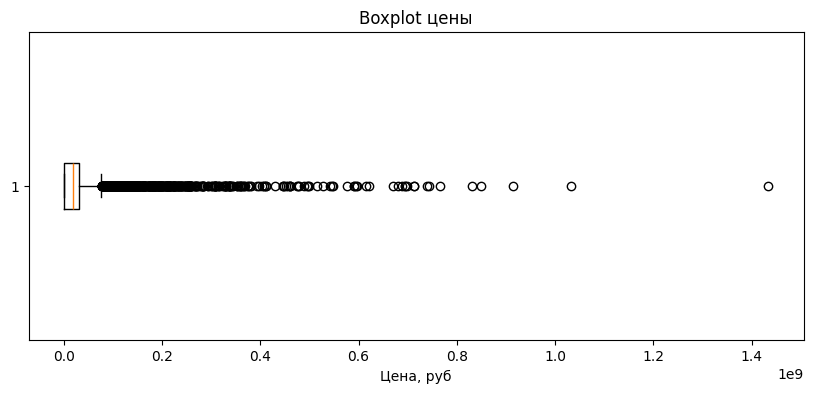

In [ ]:
plt.figure(figsize=(10, 4))
plt.boxplot(df_clean['Цена'].dropna(), vert=False)
plt.xlabel('Цена, руб')
plt.title('Boxplot цены')
plt.show()

Явно есть сильные выбросы. Плюс цена квартиры не может быть 0 рублей. Возьмем за нижний порог - 100 000 рублей, за верхний 98-й квантиль, чтобы сохранить максимум объектов

Осталось объектов 5661 , удалено 3951


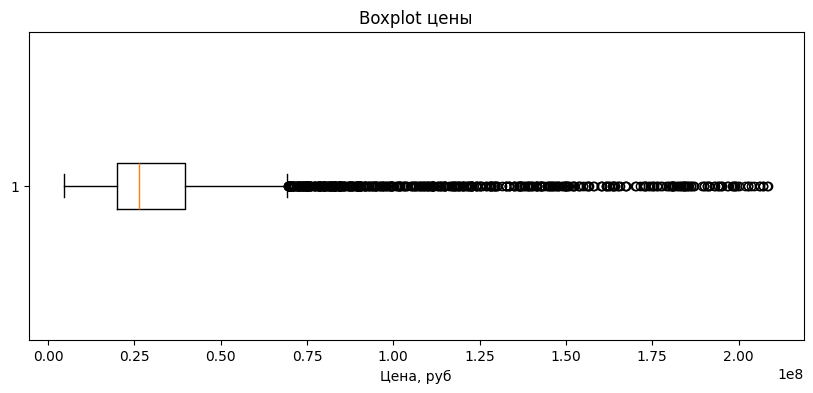

In [ ]:
lower = 100_000
upper = df['Цена'].quantile(0.98)
n = len(df)
df_clean = df[(df['Цена'] >= 1000) & (df['Цена'] <= upper)]
print('Осталось объектов', len(df_clean), ', удалено', n-len(df_clean))

plt.figure(figsize=(10, 4))
plt.boxplot(df_clean['Цена'].dropna(), vert=False)
plt.xlabel('Цена, руб')
plt.title('Boxplot цены')
plt.show()

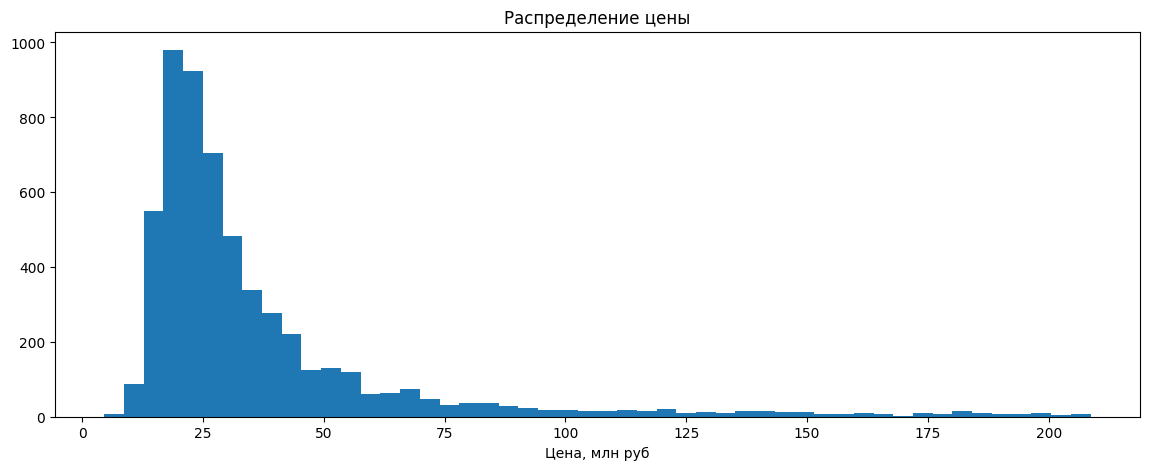

In [ ]:
plt.figure(figsize=(14, 5))
plt.hist(df_clean['Цена']/10**6, bins=50)
plt.title('Распределение цены')
plt.xlabel('Цена, млн руб')
plt.show()


Большинство квартир стоят до 50 млн рублей. Есть небольшое количество дорогих объектов, которые тянут хвост вправо, но это нормально для рынка недвижимости.

Теперь перейдем к анализу метрик. Рассмотрим признаки, которые имеют среднюю и сильную корреляцию с каким-то отличным от самих признаком

In [ ]:
df_clean['Грузовой лифт']

,Грузовой лифт
0,1
1,1
2,0
3,1
5,1
...,...
9586,1
9590,1
9607,1
9610,1


/tmp/ipykernel_2915/3257845336.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Грузовой лифт'] = df_clean['Грузовой лифт'].map({'Есть': 1, 'Нет': 0})


,count
Грузовой лифт,
1,5246
0,415


In [ ]:
#corr_matrix = df_clean.drop(columns=['Метро', 'АО', 'Строительнаяготовность']).corr()
corr_matrix = df_clean.drop(columns=['Метро','Строительнаяготовность']).corr()

useful_cols = corr_matrix[(corr_matrix.abs() > 0.5).sum() > 1].index

plt.figure(figsize=(16, 16))
sns.heatmap(
    corr_matrix.loc[useful_cols, useful_cols],
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.3
)
plt.title('Матрица корреляций')
plt.show()

ValueError: could not convert string to float: 'Есть'


Матрица корреляций показывает достаточно много признаков сильно связаны друг с другом.

На цену больше всего влияет площадь (0.72), жилая площадь (0.67) и количество комнат (0.46). Логично, чем больше квартира, тем дороже.

Также видно что некоторые признаки почти полностью дублируют друг друга. Например, Аккредитация, Продажаквартирчерез эскроу, ПервичноеЖилье имеют корреляции 0.97–0.99, это один и тот же смысл.
Из этой тройки (Аккредитация, Продажаквартирчерез эскроу, ПервичноеЖилье) можно оставить один признак — ПервичноеЖилье как наиболее понятный.

Год постройки и ПервичноеЖилье — -1.0, сильная линейная зависимость
Материалстен_Монолитно-кирпичный и Материалстен_Монолитный — -0.93


In [ ]:
corr_target = df_clean.drop(columns=['Метро']).corr()['Цена'].drop('Цена').sort_values()

plt.figure(figsize=(8, 12))
corr_target.plot(kind='barh')
plt.title('Корреляция признаков с ценой')
plt.show()

ValueError: could not convert string to float: 'Есть'

Если более детально посмотреть на корреляции с ценой — сильнее всего влияют площадные признаки Площадь, Жилая, Кухня, Комнат. Далее идут характеристики жилья Класс жилья и Качество воздуха. Чуть слабее — Высота потолков и Этаж. Всё остальное практически не коррелирует с ценой линейно.
Интересно что Газ и Время до метро уходят в минус. Вероятно газифицированные дома это старый фонд, а далеко от метро дешевле.

Связи с округом сейчас оставим без внимания, их мы проанализируем дальше

Гипотеза 1. Чем больше площадь - тем выше цена. Уже видно из матрицы (0.72), но интересно посмотреть есть ли линейная зависимость или она ломается на очень больших площадях.

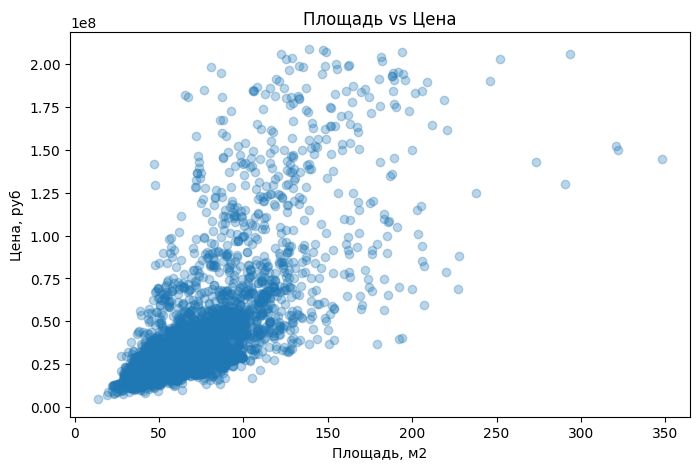

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['Площадь'], df_clean['Цена'], alpha=0.3)
plt.xlabel('Площадь, м2')
plt.ylabel('Цена, руб')
plt.title('Площадь vs Цена')
plt.show()

Гипотеза 2. Первичное жильё дороже вторичного при одинаковой площади — новостройки продаются с наценкой за новизну и инфраструктуру.

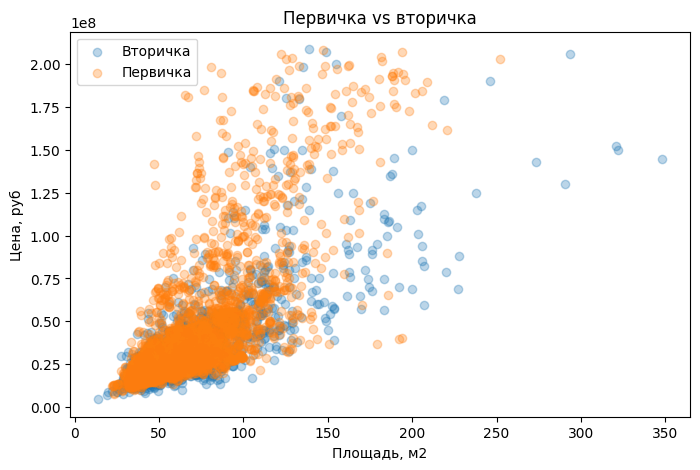

In [ ]:
plt.figure(figsize=(8, 5))
for val, label in [(0, 'Вторичка'), (1, 'Первичка')]:
    mask = df_clean['ПервичноеЖилье'] == val
    plt.scatter(df_clean[mask]['Площадь'], df_clean[mask]['Цена'], alpha=0.3, label=label)

plt.xlabel('Площадь, м2')
plt.ylabel('Цена, руб')
plt.title('Первичка vs вторичка')
plt.legend()
plt.show()

Гипотеза 3. Чем ближе к метро — тем дороже квартира. Время до метро показывает -0.09 с ценой, но это слабо — возможно эффект нелинейный и лучше виден на группах (до 5 минут, 5–15, 15+).

/tmp/ipykernel_2915/3669498395.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Метро_группа'] = pd.cut(
/tmp/ipykernel_2915/3669498395.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('Метро_группа')['Цена'].median().plot(kind='bar')


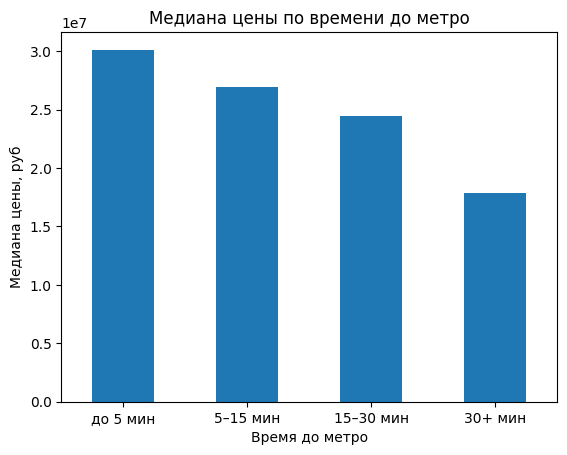

In [ ]:
df_clean['Метро_группа'] = pd.cut(
    df_clean['Время до метро'],
    bins=[0, 5, 15, 30, 100],
    labels=['до 5 мин', '5–15 мин', '15–30 мин', '30+ мин']
)

df_clean.groupby('Метро_группа')['Цена'].median().plot(kind='bar')
plt.xlabel('Время до метро')
plt.ylabel('Медиана цены, руб')
plt.title('Медиана цены по времени до метро')
plt.xticks(rotation=0)
plt.show()

Теперь попробуем проанализировать влияние округа на некоторые ключевые параметры, как цена, площадь, кол-во комнат, время до метро, кол-во этажей и состояние квартиры

In [ ]:
columns = [
    'Цена',
    'Площадь',
    'Комнат',
    'Время до метро',
    'Количествоэтажей',
    'Состояние'
]

okrug_columns = [col for col in df_clean.columns if col.startswith('АО_')]

df_corr = df_clean[columns + okrug_columns].copy()

In [ ]:
corr_matrix = df_corr.corr()

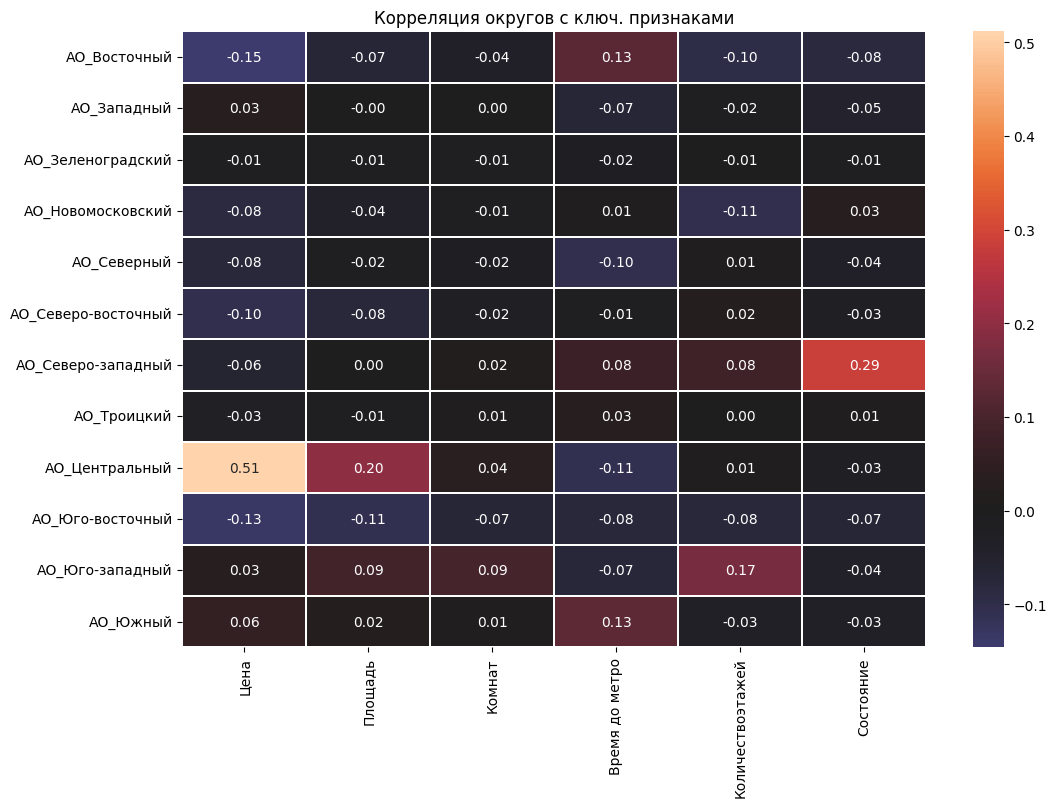

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix.loc[okrug_columns, columns],
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.3,
)

plt.title('Корреляция округов с ключ. признаками')
plt.show()


По этой корреляц. матрице можно сделать следующие выводы:

1. Заметно сильное влияние и округа цены только для объектов, у который округ - центральный (0.43)
Что удивительно, для Западного округа (который тоже считается дорогим) корреляция гораздо меньше (0.06)
А для восточного округа корреляция -(0.15), что значит, что этот округ дешевле среднего

2. Также в центральном округе корреляция с временом до метро (-0.16), в то время как в восточном - (0.12), т.е. в центральном округе метро в основном шаговой доступности, в то время как в восточом округе оно в среднем далеко от объектов

3. Состояние объектов в северо-западном округе в среднем лучше, чем в других районах. Скорее всего это связано с тем, что в последние 10 лет этот район активнее других застраивался и преобразовывался, поэтому состояние квартир там на текущий момент лучше, чем в других районах

4. Связь ключевых параметров и округа оказалась не особо существенной, большие корреляции не были замечены, из чего мы делаем вывод, что ключ. параметры объектов распределены более-менее равномерно по всем округам (кроме ЦАО)  

Теперь обратимся к переменной строительная готовность и попробуем проанализировать взаимосвязь (для новостроек) этого признака и цены

Проверим гипотезу: цена объекта и уровень его готовности - линейно зависимые величины (т.е. при увеличении уровня готовности объекта, не будет "резких" перепадов)

Построим график зависимости

<Figure size 800x500 with 0 Axes>

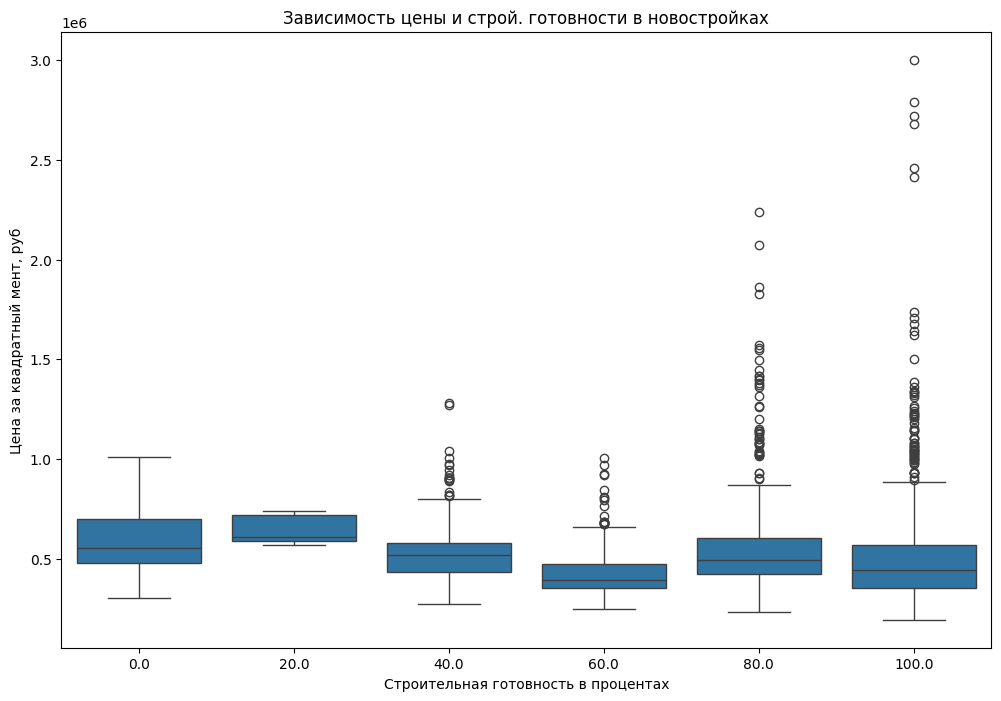

In [ ]:
import seaborn as sns
plt.figure(figsize=(8, 5))

tempMask = (df_clean['Строительнаяготовность'].notna()) & (df_clean['ПервичноеЖилье'] == 1)
plot_df = df_clean.loc[tempMask, ['Строительнаяготовность', 'Цена', 'Площадь']].copy()
plot_df['Цена_за_м^2'] = plot_df['Цена'] / plot_df['Площадь']
plot_df['Готовность_группа'] = (plot_df['Строительнаяготовность']//20)*20

plt.figure(figsize=(12, 8))
sns.boxplot(data=plot_df, x='Готовность_группа', y='Цена_за_м^2')

plt.xlabel('Строительная готовность в процентах')
plt.ylabel('Цена за квадратный мент, руб')
plt.title('Зависимость цены и строй. готовности в новостройках')
plt.show()

Из графика становится ясно, что на каждом уровне готовности наблюдается широкий разброс цен, и нельзя подтвердить гипотезу о линейном возрастании цены квартиры (за квадратный метр)

Также заметим, что чем больше строй. готовность, тем больше "выбросов", что вероятней всего связано с тем, что на ранних этапах строй. готовности дорогие лоты не продаются в открытую, а презентуются на закрытых показах

Таким образом, делаем вывод, что цена на новостройки не определяется уровнем готовности, а опред. другими параметрами (площадь/расположение/цена и пр.)

In [ ]:
print(df_clean[tempMask]['Цена'])

0         21640760.0
1         25984780.0
5         21225539.0
7         21635497.0
14        23741150.0
            ...     
10369    146361133.0
10371    170406885.0
10377    124068670.0
10381    131400000.0
10431    175000000.0
Name: Цена, Length: 3058, dtype: float64


Первая гипотеза заключается в том, что состояние квартиры влияет на ее цену по-разному в зависимости от сегмента жилья. Предполагается, что хороший ремонт сильнее повышает стоимость 1–2-комнатных квартир, особенно на вторичном рынке, тогда как для более крупных объектов или части новостроек этот эффект может быть слабее.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

h1 = df_clean[['Цена', 'Площадь', 'Комнат', 'Состояние', 'ПервичноеЖилье']].copy()

h1 = h1.dropna()
h1 = h1[(h1['Цена'] > 0) & (h1['Площадь'] > 0) & (h1['Комнат'] > 0)]

h1['Цена_за_м2'] = h1['Цена'] / h1['Площадь']

low = h1['Цена_за_м2'].quantile(0.01)
high = h1['Цена_за_м2'].quantile(0.99)
h1 = h1[(h1['Цена_за_м2'] >= low) & (h1['Цена_за_м2'] <= high)]

repair_names = {
    0: 'Без ремонта',
    1: 'Предчистовая',
    2: 'Средний',
    3: 'Косметический',
    4: 'Чистовая',
    5: 'Евроремонт'
}
h1['Состояние_текст'] = h1['Состояние'].map(repair_names)

h1['Сегмент_комнат'] = np.where(
    h1['Комнат'] == 1, '1-комнатные',
    np.where(h1['Комнат'] == 2, '2-комнатные', '3+ комнатные')
)

h1['Тип_жилья'] = h1['ПервичноеЖилье'].map({
    0: 'Вторичка',
    1: 'Первичка'
})

summary_h1 = (
    h1.groupby(['Тип_жилья', 'Сегмент_комнат', 'Состояние_текст'])
      .agg(
          Количество=('Цена', 'size'),
          Медианная_цена_за_м2=('Цена_за_м2', 'median')
      )
      .reset_index()
      .sort_values(['Тип_жилья', 'Сегмент_комнат', 'Состояние_текст'])
)

print(summary_h1)

   Тип_жилья Сегмент_комнат Состояние_текст  Количество  Медианная_цена_за_м2
0   Вторичка    1-комнатные      Евроремонт          15         433333.333333
1   Вторичка    1-комнатные   Косметический          25         376712.328767
2   Вторичка    1-комнатные         Средний         287         467980.295567
3   Вторичка    1-комнатные        Чистовая          18         584050.000000
4   Вторичка    2-комнатные      Евроремонт          34         420493.469127
5   Вторичка    2-комнатные   Косметический          38         399004.424779
6   Вторичка    2-комнатные         Средний         441         448101.265823
7   Вторичка    2-комнатные        Чистовая          21         455331.412104
8   Вторичка   3+ комнатные      Евроремонт          23         406578.947368
9   Вторичка   3+ комнатные   Косметический          32         352118.765828
10  Вторичка   3+ комнатные    Предчистовая           1         336653.386454
11  Вторичка   3+ комнатные         Средний         450         

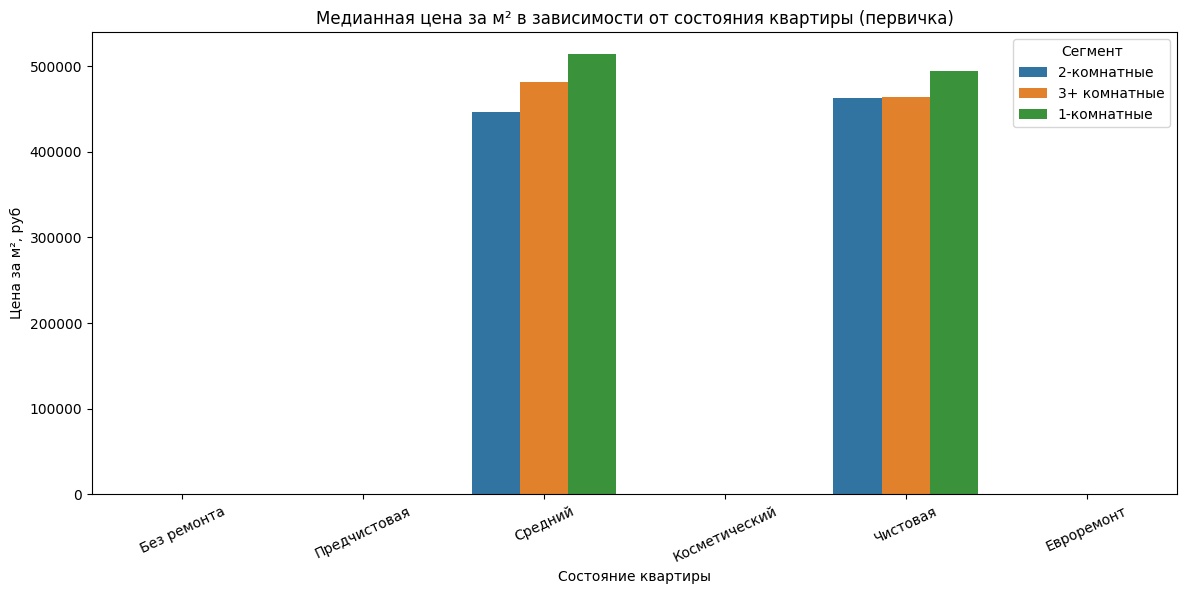

In [ ]:
state_order = [
    'Без ремонта',
    'Предчистовая',
    'Средний',
    'Косметический',
    'Чистовая',
    'Евроремонт'
]







plt.figure(figsize=(14, 6))
sns.barplot(
    data=h1[h1['Тип_жилья'] == 'Первичка'],
    x='Состояние_текст',
    y='Цена_за_м2',
    hue='Сегмент_комнат',
    order=state_order,
    estimator=np.median,
    errorbar=None
)

plt.title('Медианная цена за м² в зависимости от состояния квартиры (первичка)')
plt.xlabel('Состояние квартиры')
plt.ylabel('Цена за м², руб')
plt.xticks(rotation=25)
plt.legend(title='Сегмент')
plt.show()

In [ ]:
pivot_h1 = summary_h1.pivot_table(
    index=['Тип_жилья', 'Сегмент_комнат'],
    columns='Состояние_текст',
    values='Медианная_цена_за_м2'
)

pivot_h1

Состояние_текст              Евроремонт  Косметический   Предчистовая  \
Тип_жилья Сегмент_комнат                                                
Вторичка  1-комнатные     433333.333333  376712.328767            NaN   
          2-комнатные     420493.469127  399004.424779            NaN   
          3+ комнатные    406578.947368  352118.765828  336653.386454   
Первичка  1-комнатные               NaN            NaN            NaN   
          2-комнатные               NaN            NaN            NaN   
          3+ комнатные              NaN            NaN            NaN   

Состояние_текст                 Средний       Чистовая  
Тип_жилья Сегмент_комнат                                
Вторичка  1-комнатные     467980.295567  584050.000000  
          2-комнатные     448101.265823  455331.412104  
          3+ комнатные    465737.530008  433278.767123  
Первичка  1-комнатные     513800.000000  494100.000000  
          2-комнатные     446687.991803  462552.788991  
          3+ комнатные    481020.778443  464007.728127

Вывод по первой гипотезе: проверка показала, что влияние состояния квартиры на цену действительно зависит от сегмента жилья. На вторичном рынке прослеживается более понятная связь: в сегментах 1- и 2-комнатных квартир объекты в лучшем состоянии в среднем имеют более высокую цену за квадратный метр. Это означает, что для вторичного жилья ремонт и уровень отделки действительно могут выступать фактором ценовой премии. Для первичного рынка такой зависимости выявлено не было: различия между категориями состояния оказались менее устойчивыми и не образуют явного тренда. Следовательно, первая гипотеза подтверждается частично: состояние квартиры влияет на цену, но этот эффект сильнее проявляется на вторичном рынке и зависит от типа объекта.

Отсутствие части значений в сводной таблице объясняется не ошибкой в расчетах, а особенностями выборки. Для некоторых сочетаний типа жилья, числа комнат и состояния квартиры в исходных данных просто не оказалось наблюдений, либо после очистки данных таких объектов осталось слишком мало. Поэтому в таблице для этих категорий отображаются пропуски, и по ним нельзя делать содержательные выводы.

Вторая гипотеза заключается в том, что для квартир с одинаковым числом комнат и сопоставимой общей площадью цена зависит не только от размера квартиры, но и от эффективности планировки. Предполагается, что квартиры с более удобным распределением площади, например с большей площадью на комнату, могут стоить дороже за квадратный метр.

In [ ]:
h2 = df_clean[['Цена', 'Площадь', 'Комнат']].copy()

h2 = h2.dropna()
h2 = h2[(h2['Цена'] > 0) & (h2['Площадь'] > 0) & (h2['Комнат'] > 0)]

h2['Цена_за_м2'] = h2['Цена'] / h2['Площадь']
h2['Площадь_на_комнату'] = h2['Площадь'] / h2['Комнат']

In [ ]:
low_price = h2['Цена_за_м2'].quantile(0.01)
high_price = h2['Цена_за_м2'].quantile(0.99)

low_room = h2['Площадь_на_комнату'].quantile(0.01)
high_room = h2['Площадь_на_комнату'].quantile(0.99)

h2 = h2[
    (h2['Цена_за_м2'] >= low_price) & (h2['Цена_за_м2'] <= high_price) &
    (h2['Площадь_на_комнату'] >= low_room) & (h2['Площадь_на_комнату'] <= high_room)
].copy()

In [ ]:
h2['Сегмент_комнат'] = np.where(
    h2['Комнат'] == 1, '1-комнатные',
    np.where(h2['Комнат'] == 2, '2-комнатные', '3+ комнатные')
)

In [ ]:
h2['Группа_площади'] = pd.cut(
    h2['Площадь'],
    bins=[0, 40, 55, 70, 90, 130, 300],
    labels=['до 40', '40-55', '55-70', '70-90', '90-130', '130+']
)

In [ ]:
def safe_qcut(series):
    if series.notna().sum() < 20 or series.nunique() < 4:
        return pd.Series(np.nan, index=series.index)
    return pd.qcut(
        series,
        4,
        labels=['Q1 низкий', 'Q2', 'Q3', 'Q4 высокий'],
        duplicates='drop'
    )

h2['Квартиль_планировки'] = (
    h2.groupby(['Сегмент_комнат', 'Группа_площади'])['Площадь_на_комнату']
      .transform(safe_qcut)
)

/tmp/ipykernel_3142/820582353.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h2.groupby(['Сегмент_комнат', 'Группа_площади'])['Площадь_на_комнату']


In [ ]:
summary_h2 = (
    h2.groupby(['Сегмент_комнат', 'Группа_площади', 'Квартиль_планировки'])
      .agg(
          Количество=('Цена', 'size'),
          Медианная_цена_за_м2=('Цена_за_м2', 'median')
      )
      .reset_index()
)

summary_h2 = summary_h2[summary_h2['Количество'] >= 15]
summary_h2

/tmp/ipykernel_3142/3478610501.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h2.groupby(['Сегмент_комнат', 'Группа_площади', 'Квартиль_планировки'])


,Сегмент_комнат,Группа_площади,Квартиль_планировки,Количество,Медианная_цена_за_м2
0,1-комнатные,до 40,Q1 низкий,226,510187.509653
1,1-комнатные,до 40,Q2,226,484700.000000
2,1-комнатные,до 40,Q3,208,492250.000000
3,1-комнатные,до 40,Q4 высокий,215,476200.000000
4,1-комнатные,40-55,Q1 низкий,203,478526.144279
5,1-комнатные,40-55,Q2,204,487825.333355
6,1-комнатные,40-55,Q3,198,524190.890063
7,1-комнатные,40-55,Q4 высокий,201,566789.219331
8,1-комнатные,55-70,Q1 низкий,17,777904.159132
9,1-комнатные,55-70,Q2,16,748556.493751


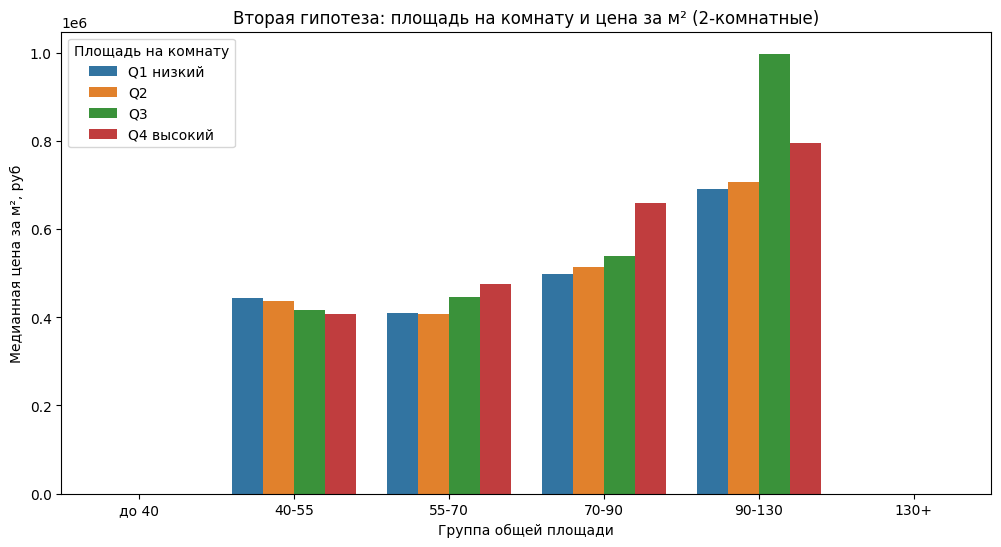

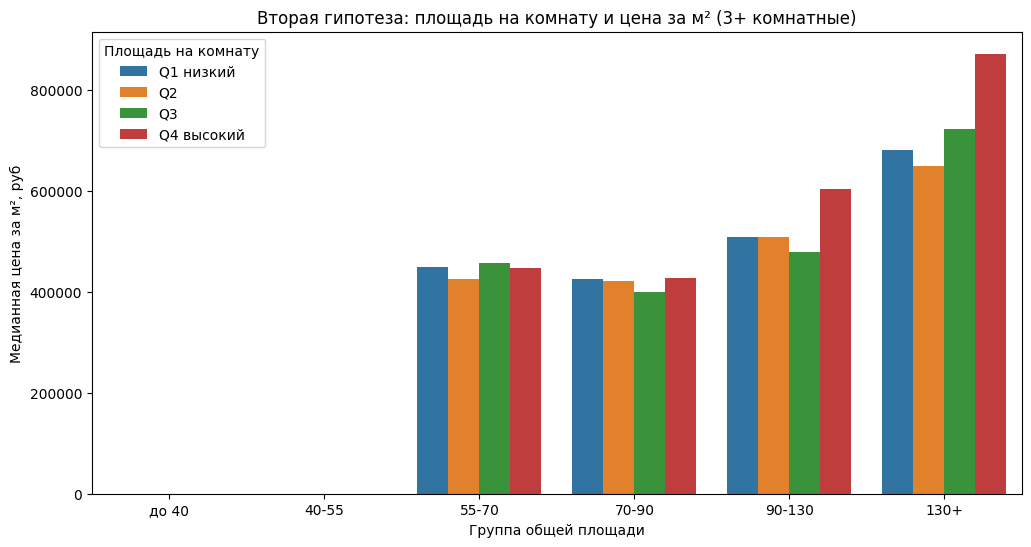

In [ ]:
for seg in ['2-комнатные', '3+ комнатные']:
    temp = summary_h2[summary_h2['Сегмент_комнат'] == seg]

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=temp,
        x='Группа_площади',
        y='Медианная_цена_за_м2',
        hue='Квартиль_планировки'
    )

    plt.title(f'Вторая гипотеза: площадь на комнату и цена за м² ({seg})')
    plt.xlabel('Группа общей площади')
    plt.ylabel('Медианная цена за м², руб')
    plt.legend(title='Площадь на комнату')
    plt.show()

Вывод по второй гипотезе: проверка показала, что влияние показателя «площадь на комнату» на цену квартиры нельзя считать одинаковым для всех сегментов, однако в ряде групп связь действительно прослеживается. Наиболее заметно это видно для 2-комнатных квартир площадью 55–90 м², где при увеличении площади на комнату медианная цена за квадратный метр возрастает, а также для 3-комнатных и более квартир в группах 90–130 м² и 130+ м², где квартиры с более высокой площадью на комнату стоят дороже. Вместе с тем в ряде других сегментов, например среди 1-комнатных квартир до 40 м² или 2-комнатных квартир площадью 40–55 м², такой закономерности не наблюдается. Следовательно, вторая гипотеза подтверждается частично: эффективность распределения площади действительно может быть связана с более высокой ценой за квадратный метр, но этот эффект проявляется не на всем рынке, а главным образом в более просторных квартирах.

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.4 MB/s eta 0:00:00


влияние каждой переменной на цену, цену за метр

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from catboost import CatBoostRegressor

In [ ]:
df_imp = df_clean.copy()
df_imp = df_imp[(df_imp['Цена'] > 0) & (df_imp['Площадь'] > 0)].copy()

In [ ]:
df_imp['Площадь'] > 0

,Площадь
0,True
1,True
2,True
3,True
5,True
...,...
10454,True
10458,True
10476,True
10479,True


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from catboost import CatBoostRegressor

df_imp = df_clean.copy()

df_imp = df_imp[(df_imp['Цена'] > 0) & (df_imp['Площадь'] > 0)].copy()

df_imp['Цена_за_м2'] = df_imp['Цена'] / df_imp['Площадь']

use_cols = [
    'Площадь',
    'Жилая',
    'Кухня',
    'Комнат',
    'Этаж',
    'Количествоэтажей',
    'Высота потолков',
    'Год постройки',
    'ПервичноеЖилье',
    'Состояние',
    'Метро',
    'Время до метро',
    'Строительнаяготовность'
]

use_cols = [col for col in use_cols if col in df_imp.columns]

X = df_imp[use_cols].copy()
y = df_imp['Цена_за_м2'].copy()

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype(str)
    X[col] = X[col].replace('nan', 'Неизвестно')
    X[col] = X[col].fillna('Неизвестно')

for col in X.columns:
    if col not in cat_cols:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        X[col] = X[col].fillna(X[col].median())

#train+temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

#temp на valid и test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print('train:', X_train.shape)
print('valid:', X_valid.shape)
print('test:', X_test.shape)

cat_features_idx = [X.columns.get_loc(col) for col in cat_cols]








model = CatBoostRegressor(
    iterations=700,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    eval_metric='RMSE',
    verbose=100,
    random_seed=42
)

model.fit(
    X_train, y_train,
    cat_features=cat_features_idx,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

#проверим на тесте))))
pred_test = model.predict(X_test)
mape_test = mean_absolute_percentage_error(y_test, pred_test)

print('Тестовый MAPE:', round(mape_test * 100, 2), '%')

importance = pd.DataFrame({
    'Фактор': X.columns,
    'Важность': model.get_feature_importance()
})

importance = importance.sort_values('Важность', ascending=False).reset_index(drop=True)
importance['Доля_влияния_%'] = 100 * importance['Важность'] / importance['Важность'].sum()

importance

train: (3396, 13)
valid: (1132, 13)
test: (1133, 13)
0:	learn: 239111.0692094	test: 242958.4028515	best: 242958.4028515 (0)	total: 99.1ms	remaining: 1m 9s
100:	learn: 126941.2009587	test: 131979.7449051	best: 131979.7449051 (100)	total: 966ms	remaining: 5.73s
200:	learn: 109246.6638267	test: 120944.9214984	best: 120944.9214984 (200)	total: 1.91s	remaining: 4.75s
300:	learn: 96558.4909976	test: 115260.3202825	best: 115260.3202825 (300)	total: 2.81s	remaining: 3.72s
400:	learn: 88350.0166578	test: 112465.4535128	best: 112433.8494825 (395)	total: 3.78s	remaining: 2.82s
500:	learn: 82169.4337769	test: 110298.5626424	best: 110293.4638886 (498)	total: 4.24s	remaining: 1.68s
600:	learn: 76695.1770589	test: 108761.2051906	best: 108707.4810175 (588)	total: 4.58s	remaining: 754ms
699:	learn: 72505.3657702	test: 107868.6059391	best: 107868.6059391 (699)	total: 4.9s	remaining: 0us

bestTest = 107868.6059
bestIteration = 699

Тестовый MAPE: 12.49 %


,Фактор,Важность,Доля_влияния_%
0,Метро,34.439939,34.439939
1,Количествоэтажей,15.559475,15.559475
2,Жилая,11.126613,11.126613
3,Время до метро,9.397668,9.397668
4,Строительнаяготовность,7.163936,7.163936
5,Комнат,5.412580,5.412580
6,Кухня,4.895344,4.895344
7,Этаж,3.076325,3.076325
8,Год постройки,2.991000,2.991000
9,Площадь,2.949804,2.949804


In [ ]:
z = pd.DataFrame()
z['1'] = y_test
z['2'] = pred_test

z

,1,2
7986,373383.000000,379312.965450
2797,424591.094421,444358.661457
6107,317000.000000,425283.466658
7621,329811.990521,387749.044056
6285,698100.000000,656838.345788
...,...,...
9039,368881.973094,426527.442602
9101,614377.917526,503331.274819
5551,523000.000000,486566.562419
7378,660000.000000,561798.653167


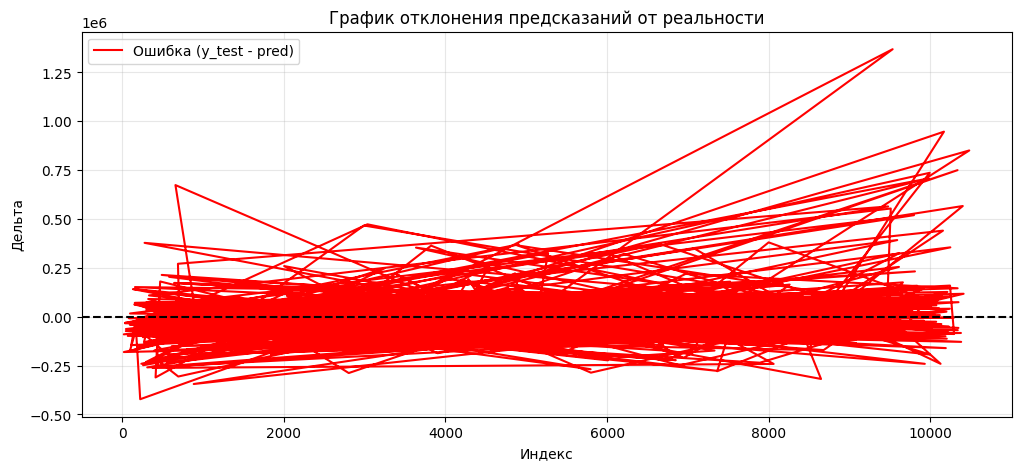

In [ ]:
z['delta'] = z['1'] - z['2']

plt.figure(figsize=(12, 5))
plt.plot(z['delta'], color='red', label='Ошибка (y_test - pred)')
plt.axhline(y=0, color='black', linestyle='--') # Линия нулевой ошибки

plt.title('График отклонения предсказаний от реальности')
plt.xlabel('Индекс')
plt.ylabel('Дельта')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

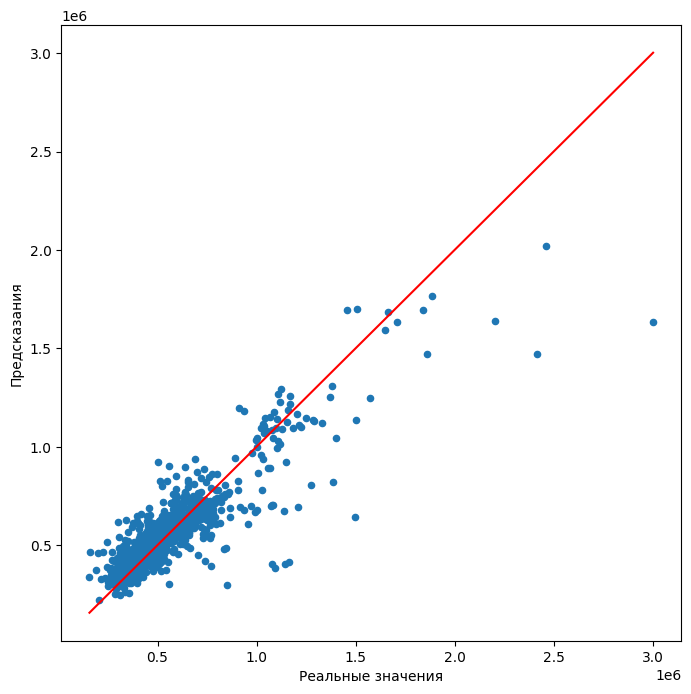

In [ ]:
z.plot.scatter(x='1', y='2', figsize=(8, 8))
plt.plot([z['1'].min(), z['1'].max()], [z['1'].min(), z['1'].max()], color='red') # Линия идеальных предсказаний
plt.xlabel('Реальные значения')
plt.ylabel('Предсказания')
plt.show()

In [130]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from catboost import CatBoostRegressor

df_imp = df_clean.copy()
df_imp = df_imp[(df_imp['Цена'] > 0) & (df_imp['Площадь'] > 0)].copy()
y = df_imp['Цена'].copy()
use_cols = [col for col in df.columns if col in df_imp.columns and col != 'Цена']

X = df_imp[use_cols].copy()

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype(str)
    X[col] = X[col].replace('nan', 'Неизвестно')
    X[col] = X[col].fillna('Неизвестно')

for col in X.columns:
    if col not in cat_cols:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        X[col] = X[col].fillna(X[col].median())

# train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

#temp на valid и test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print('train:', X_train.shape)
print('valid:', X_valid.shape)
print('test:', X_test.shape)

cat_features_idx = [X.columns.get_loc(col) for col in cat_cols]

model = CatBoostRegressor(
    iterations=700,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    eval_metric='RMSE',
    verbose=100,
    random_seed=42
)









model.fit(
    X_train, y_train,
    cat_features=cat_features_idx,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

pred_test = model.predict(X_test)
mape_test = mean_absolute_percentage_error(y_test, pred_test)

print('Тестовый MAPE:', round(mape_test * 100, 2), '%')

importance = pd.DataFrame({
    'Фактор': X.columns,
    'Важность': model.get_feature_importance()
})

importance = importance.sort_values('Важность', ascending=False).reset_index(drop=True)
importance['Доля_влияния_%'] = 100 * importance['Важность'] / importance['Важность'].sum()

importance

train: (3396, 54)
valid: (1132, 54)
test: (1133, 54)
0:	learn: 29400570.3597072	test: 30432850.8581096	best: 30432850.8581096 (0)	total: 6.38ms	remaining: 4.46s
100:	learn: 10095481.0686399	test: 12056639.4473252	best: 12056639.4473252 (100)	total: 557ms	remaining: 3.3s
200:	learn: 8554513.5875233	test: 11074333.6314469	best: 11073069.9718038 (199)	total: 1.09s	remaining: 2.71s
300:	learn: 7359407.6072920	test: 10485525.7408040	best: 10485525.7408040 (300)	total: 1.65s	remaining: 2.19s
400:	learn: 6443842.8627789	test: 10058516.8575167	best: 10058516.8575167 (400)	total: 2.18s	remaining: 1.62s
500:	learn: 5817736.9122613	test: 9738878.6141241	best: 9738878.6141241 (500)	total: 2.79s	remaining: 1.11s
600:	learn: 5192016.5487163	test: 9479820.0784943	best: 9479820.0784943 (600)	total: 3.32s	remaining: 547ms
699:	learn: 4743602.8270650	test: 9327434.2914915	best: 9324009.0065783 (696)	total: 3.87s	remaining: 0us

bestTest = 9324009.007
bestIteration = 696

Shrink model to first 697 iterat

,Фактор,Важность,Доля_влияния_%
0,Площадь,23.724079,23.724079
1,Жилая,14.547565,14.547565
2,Класс жилья,14.034561,14.034561
3,АО_Центральный,11.220023,11.220023
4,Метро,6.330888,6.330888
5,Кухня,4.264679,4.264679
6,Качество воздуха,3.486666,3.486666
7,Количествоэтажей,3.342330,3.342330
8,Время до метро,2.624689,2.624689
9,Строительнаяготовность,2.271822,2.271822


In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from catboost import CatBoostRegressor

df_imp = df_clean.copy()
df_imp = df_imp[(df_imp['Цена'] > 0) & (df_imp['Площадь'] > 0)].copy()

q_low = df_imp['Цена'].quantile(0.01)
q_high = df_imp['Цена'].quantile(0.99)
df_imp = df_imp[(df_imp['Цена'] >= q_low) & (df_imp['Цена'] <= q_high)].copy()

# Новые признаки
df_imp['Жилая_доля'] = df_imp['Жилая'] / df_imp['Площадь']
df_imp['Кухня_доля'] = df_imp['Кухня'] / df_imp['Площадь']
df_imp['Не_первый_не_последний'] = (
    (df_imp['Этаж'] > 1) & (df_imp['Этаж'] < df_imp['Количествоэтажей'])
).astype(int)
df_imp['Этаж_от_верха'] = df_imp['Количествоэтажей'] - df_imp['Этаж']

# Признаки
use_cols = [col for col in df_imp.columns if col != 'Цена']
X = df_imp[use_cols].copy()

# Лог-цена как таргет
y = np.log1p(df_imp['Цена'])

# Убираем нулевые важности (из прошлого запуска)
zero_importance = [
    'Перепланировка', 'Тип перекрытий_Бетонный',
    'Тип сделки_Первичная продажа', 'Материалстен_Панельный', 'АО_Зеленоградский'
]
X = X.drop(columns=zero_importance, errors='ignore')

# Категориальные
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype(str).replace('nan', 'Неизвестно').fillna('Неизвестно')
for col in X.columns:
    if col not in cat_cols:
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(X[col].median())

# Сплит
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

cat_features_idx = [X.columns.get_loc(col) for col in cat_cols]

model = CatBoostRegressor(
    iterations=2000,
    depth=7,
    learning_rate=0.03,
    l2_leaf_reg=5,
    min_data_in_leaf=20,
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=100,
    verbose=200,
    random_seed=42
)

model.fit(
    X_train, y_train,
    cat_features=cat_features_idx,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

# Обратная трансформация
pred_test = np.expm1(model.predict(X_test))
mape_test = mean_absolute_percentage_error(np.expm1(y_test), pred_test)
print('Тестовый MAPE:', round(mape_test * 100, 2), '%')

# Важность
importance = pd.DataFrame({
    'Фактор': X.columns,
    'Важность': model.get_feature_importance()
}).sort_values('Важность', ascending=False).reset_index(drop=True)
importance['Доля_влияния_%'] = 100 * importance['Важность'] / importance['Важность'].sum()
importance

0:	learn: 0.5322758	test: 0.5312763	best: 0.5312763 (0)	total: 18.9ms	remaining: 37.7s
200:	learn: 0.1678048	test: 0.1849943	best: 0.1849943 (200)	total: 3.44s	remaining: 30.8s
400:	learn: 0.1369883	test: 0.1670376	best: 0.1670376 (400)	total: 5.27s	remaining: 21s
600:	learn: 0.1185891	test: 0.1586589	best: 0.1586589 (600)	total: 7.17s	remaining: 16.7s
800:	learn: 0.1056793	test: 0.1536364	best: 0.1536364 (800)	total: 9s	remaining: 13.5s
1000:	learn: 0.0954536	test: 0.1505461	best: 0.1505461 (1000)	total: 10.8s	remaining: 10.8s
1200:	learn: 0.0876436	test: 0.1484346	best: 0.1484319 (1199)	total: 12.7s	remaining: 8.48s
1400:	learn: 0.0808091	test: 0.1467568	best: 0.1467443 (1399)	total: 16.3s	remaining: 6.96s
1600:	learn: 0.0749433	test: 0.1456925	best: 0.1456921 (1598)	total: 18.1s	remaining: 4.52s
1800:	learn: 0.0704160	test: 0.1450236	best: 0.1450236 (1800)	total: 20s	remaining: 2.21s
1999:	learn: 0.0664034	test: 0.1444870	best: 0.1444870 (1999)	total: 21.9s	remaining: 0us

bestTest 

,Фактор,Важность,Доля_влияния_%
0,Площадь,29.545797,29.545797
1,Метро,14.595416,14.595416
2,Класс жилья,12.209574,12.209574
3,АО_Центральный,7.697677,7.697677
4,Жилая,3.988770,3.988770
5,Качество воздуха,2.772430,2.772430
6,Кухня,2.683435,2.683435
7,Количествоэтажей,2.518211,2.518211
8,Время до метро,2.422153,2.422153
9,Жилая_доля,1.875386,1.875386


In [ ]:
z = pd.DataFrame()
z['1'] = y_test
z['2'] = pred_test

z['3'] = y_test - pred_test
z

,1,2,3
7986,373383.000000,368452.711269,4930.288731
2797,424591.094421,425520.895959,-929.801538
6107,317000.000000,334609.111250,-17609.111250
7621,329811.990521,332275.789871,-2463.799350
6285,698100.000000,695895.989887,2204.010113
...,...,...,...
9039,368881.973094,367117.458663,1764.514431
9101,614377.917526,592137.329018,22240.588508
5551,523000.000000,524396.408523,-1396.408523
7378,660000.000000,661015.900726,-1015.900726


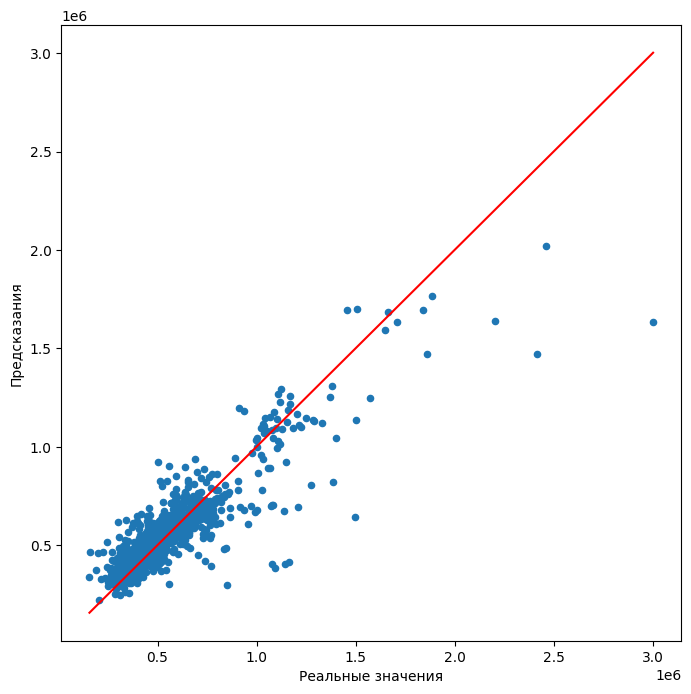

In [ ]:
z.plot.scatter(x='1', y='2', figsize=(8, 8))
plt.plot([z['1'].min(), z['1'].max()], [z['1'].min(), z['1'].max()], color='red') # Линия идеальных предсказаний
plt.xlabel('Реальные значения')
plt.ylabel('Предсказания')
plt.show()